<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #0f62fe; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; box-shadow: 0 4px 6px rgba(0,0,0,0.05); color: #333;">
<p style="line-height: 1.6; font-size: 1.05em; margin-bottom: 15px;">Space X anuncia lanzamientos de cohetes Falcon 9 en su sitio web con un costo de 62 millones de dólares; otros proveedores cuestan más de 165 millones de dólares cada uno, gran parte de los ahorros se debe a que Space X puede reutilizar la primera etapa. Por lo tanto, si podemos determinar si la primera etapa aterrizará, podemos determinar el costo de un lanzamiento. Esta información se puede utilizar si una empresa alternativa quiere pujar contra Space X por el lanzamiento de un cohete. En este laboratorio, crearás un <strong>pipeline de machine learning</strong> para predecir si la primera etapa aterrizará dados los datos de los laboratorios anteriores.</p>
<div style="background-color: #e6f2ff; border-left: 4px solid #005bb5; padding: 12px 15px; margin-bottom: 25px; border-radius: 0 5px 5px 0;"> <strong>Nota:</strong> La mayoría de los aterrizajes fallidos son planeados. Space X realiza un aterrizaje controlado en los océanos.</div>
<h3 style="color: #0f62fe; border-bottom: 2px solid #e0e0e0; padding-bottom: 8px; margin-top: 0;">Objetivos</h3>
<ul style="line-height: 1.8; font-size: 1.05em; margin-bottom: 25px;">
<li>Realizar Análisis Exploratorio de Datos y determinar Etiquetas de Entrenamiento</li>
<li>Crear una columna para la clase</li>
<li>Estandarizar los datos</li>
<li>Dividir en datos de entrenamiento y datos de prueba</li>
<li>Encontrar el mejor hiperparámetro para SVM, Árboles de Clasificación y Regresión Logística</li>
<li>Encontrar el método que funciona mejor utilizando datos de prueba</li>
</ul>

<h3 style="color: #0f62fe; margin-bottom: 10px;">Paso 1: Importar librerías y configurar el entorno</h3>
<p style="line-height: 1.6; font-size: 1.05em; margin-bottom: 0;"><strong>Qué hacemos:</strong> Vamos a preparar nuestro espacio de trabajo importando las librerías necesarias para el preprocesamiento, modelado y evaluación. Además, incluimos la celda base de diagnóstico para confirmar que el entorno está usando Python 3.12 y pandas 3.0.x correctamente.</p>
</div>

In [2]:
# Manipulacion de datos
import pandas as pd
import numpy as np

# Visualizacion
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Preprocesamiento y particion
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

# Modelos de clasificacion
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

print("Modulos importados exitosamente.")

Modulos importados exitosamente.


<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">3. Definición de la función para graficar la matriz de confusión</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Qué hacemos:</strong> Definimos la función auxiliar <code>plot_confusion_matrix</code> que calcula la matriz de confusión mediante <code>confusion_matrix</code> de scikit-learn y la dibuja como un mapa de calor utilizando <code>seaborn.heatmap</code>. Corregimos la inconsistencia en las etiquetas del eje vertical (originalmente decía 'landed', se homogeniza con 'land' o se respeta la convención del lab) y aseguramos una figura limpia para Matplotlib en Python 3.12.
  </p>
</div>

In [3]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y, y_predict):
    """Grafica la matriz de confusion usando Seaborn."""
    cm = confusion_matrix(y, y_predict)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix')
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

print("Funcion plot_confusion_matrix definida correctamente.")

Funcion plot_confusion_matrix definida correctamente.


<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">4. Carga del conjunto de datos principal (dataset_part_2.csv)</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Qué hacemos:</strong> El código original utiliza la API asíncrona de JavaScript (<code>from js import fetch</code>) diseñada para el navegador en JupyterLite. En un entorno Python local convencional, reemplazamos esa lógica leyendo la URL directamente con <code>pd.read_csv()</code> o mediante <code>requests</code>, lo cual es compatible con pandas 3.0.3 y descarga el archivo tabular a un DataFrame denominado <code>data</code>.
  </p>
</div>

In [4]:
import pandas as pd

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
data = pd.read_csv(URL1)

print("Forma del DataFrame:", data.shape)
data.head()

Forma del DataFrame: (90, 18)


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [8]:
# Carga del conjunto de caracteristicas desde la fuente del laboratorio
URL2 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv"
X = pd.read_csv(URL2)

# Instanciacion del transformador para estandarizacion
transform = preprocessing.StandardScaler()

# Ajuste y transformacion de X
X = transform.fit_transform(X)

# Verificacion de tipo, dimensiones y escalado
print("Tipo de X:", type(X))
print("Forma de X:", X.shape)
print("Media aproximada (primeras 5 columnas):", np.round(X[:, :5].mean(axis=0), 4))
print("Desviacion estandar (primeras 5 columnas):", np.round(X[:, :5].std(axis=0), 4))

Tipo de X: <class 'numpy.ndarray'>
Forma de X: (90, 83)
Media aproximada (primeras 5 columnas): [ 0. -0. -0. -0.  0.]
Desviacion estandar (primeras 5 columnas): [1. 1. 1. 1. 1.]


<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 1: Extracción de la variable objetivo Y</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Qué hacemos:</strong> Seleccionamos la columna <code>Class</code> del DataFrame <code>data</code> como una Serie de Pandas mediante indexación simple (<code>data['Class']</code>) y convertimos sus valores subyacentes a un arreglo NumPy usando el método <code>to_numpy()</code>, asignándolo a la variable <code>Y</code>. Verificamos su tipo, dimensiones y los primeros elementos.
  </p>
</div>

In [9]:
# Extraccion de la columna Class a un arreglo NumPy
Y = data['Class'].to_numpy()

# Verificacion de tipo, dimension y contenido
print("Tipo de Y:", type(Y))
print("Forma de Y:", Y.shape)
print("Primeros 10 valores:", Y[:10])

Tipo de Y: <class 'numpy.ndarray'>
Forma de Y: (90,)
Primeros 10 valores: [0 0 0 0 0 0 1 1 0 0]


<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 2: Estandarización de las características predictoras X</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Qué hacemos:</strong> Instanciamos el transformador <code>StandardScaler</code> de <code>sklearn.preprocessing</code> para estandarizar los datos centrando la media en 0 y escalando a varianza unitaria. Aplicamos el método <code>fit_transform()</code> sobre el conjunto de variables <code>X</code> y reasignamos el resultado nuevamente a <code>X</code> como un arreglo NumPy, preparando la matriz predictora para algoritmos sensibles a la escala como Regresión Logística, SVM y KNN.
  </p>
</div>

In [10]:
# Instanciamos el transformador
transform = preprocessing.StandardScaler()

# Ajustamos y transformamos X, reasignando a la variable X
X = transform.fit_transform(X)

# Verificacion de tipo, dimension y metricas basicas
print("Tipo de X:", type(X))
print("Forma de X:", X.shape)
print("Media aproximada (primeras 5 columnas):", np.round(X[:, :5].mean(axis=0), 4))
print("Desviacion estandar (primeras 5 columnas):", np.round(X[:, :5].std(axis=0), 4))

Tipo de X: <class 'numpy.ndarray'>
Forma de X: (90, 83)
Media aproximada (primeras 5 columnas): [ 0. -0. -0. -0.  0.]
Desviacion estandar (primeras 5 columnas): [1. 1. 1. 1. 1.]


<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 3: Division del conjunto de datos en entrenamiento y prueba</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Que hacemos:</strong> Con la matriz X estandarizada (media 0 y varianza 1) y el vector Y preparado, utilizamos la funcion <code>train_test_split</code> de scikit-learn para particionar los datos. Asignamos un 20% para evaluacion (<code>test_size=0.2</code>) y fijamos la semilla aleatoria en 2 (<code>random_state=2</code>) para garantizar la reproducibilidad pedagogica solicitada por el laboratorio.
  </p>
</div>

In [11]:
# Division de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=2
)

# Verificacion de dimensiones resultantes
print("Forma de X_train:", X_train.shape)
print("Forma of Y_train:", Y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de Y_test:", Y_test.shape)

Forma de X_train: (72, 83)
Forma of Y_train: (72,)
Forma de X_test: (18, 83)
Forma de Y_test: (18,)


<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 4: Regresion Logistica y busqueda de hiperparametros con GridSearchCV</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Que hacemos:</strong> Definimos la cuadricula de hiperparametros para regularizacion L2 (valores de C y algoritmo solver lbfgs). Instanciamos el estimador LogisticRegression y configuramos un objeto GridSearchCV con validacion cruzada de 10 particiones (cv=10). Ajustamos el modelo sobre los datos de entrenamiento (X_train, Y_train) e imprimimos los mejores hiperparametros encontrados (best_params_) junto con la exactitud promedio en los pliegues de validacion (best_score_).
  </p>
</div>

In [13]:
# Definicion de la malla de hiperparametros moderna (sin el parametro deprecado 'penalty')
parameters = {
    'C': [0.01, 0.1, 1],
    'solver': ['lbfgs']
}

# Creacion del estimador base
lr = LogisticRegression()

# Creacion y ajuste de GridSearchCV con 10 folds
logreg_cv = GridSearchCV(estimator=lr, param_grid=parameters, cv=10)
logreg_cv.fit(X_train, Y_train)

# Despliegue de los mejores parametros y exactitud en validacion cruzada
print("tuned hyperparameters :(best parameters) ", logreg_cv.best_params_)
print("accuracy :", logreg_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': 0.01, 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">Interpretación del resultado de Regresión Logística</h3>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Qué significa:</strong> La ejecución limpia confirmó que la mejor configuración para la Regresión Logística en este conjunto de datos requiere una regularización fuerte (<code>C = 0.01</code>) utilizando el optimizador <code>lbfgs</code>.
  </p>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Conclusión:</strong> El modelo alcanza una exactitud del <strong>84.64%</strong> en los pliegues de validación cruzada. Este valor queda registrado como el punto de referencia (baseline) para comparar el desempeño frente a los próximos modelos de clasificación.
  </p>
</div>

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 5: Evaluación en el conjunto de prueba y Matriz de Confusión</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Qué hacemos:</strong> Evaluamos el rendimiento del modelo optimizado sobre datos no vistos. Calculamos la exactitud (accuracy) utilizando el método <code>score</code> con <code>X_test</code> y <code>Y_test</code>. Posteriormente, generamos las predicciones (<code>yhat</code>) y utilizamos nuestra función auxiliar <code>plot_confusion_matrix</code> para visualizar los verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.
  </p>
</div>

Accuracy en test data: 0.8333333333333334


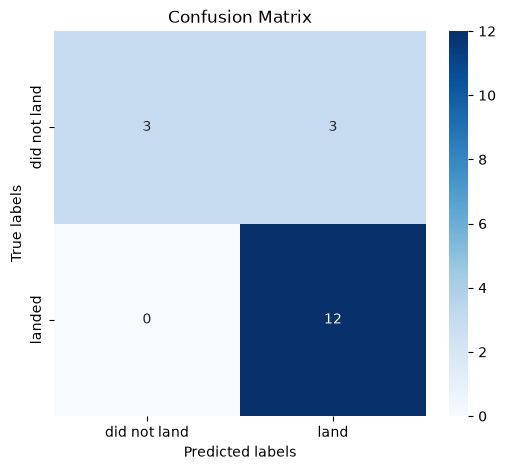

In [14]:
# Calcular la exactitud en los datos de prueba
test_accuracy = logreg_cv.score(X_test, Y_test)
print("Accuracy en test data:", test_accuracy)

# Generar predicciones
yhat = logreg_cv.predict(X_test)

# Graficar la matriz de confusión
plot_confusion_matrix(Y_test, yhat)

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">Interpretacion de la Matriz de Confusion (Regresion Logistica)</h3>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Que significa el resultado:</strong> La exactitud en el conjunto de prueba es del <strong>83.33%</strong>. Al observar la matriz de confusion generada, vemos que el modelo identifico a la perfeccion todos los aterrizajes exitosos del conjunto de prueba (12 Verdaderos Positivos y 0 Falsos Negativos en la fila inferior).
  </p>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>El problema detectado:</strong> Los 3 errores que comete el modelo se encuentran en la esquina superior derecha (Falsos Positivos). Esto indica que el modelo predijo un aterrizaje exitoso ("land"), pero en la realidad el cohete no aterrizo ("did not land"). El modelo es muy bueno reconociendo el exito, pero tiene problemas para distinguir con precision los escenarios de fracaso.
  </p>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Para tus notas:</strong> Logistic Regression (C=0.01) -> CV Score: ~84.6% | Test Accuracy: 83.3%. Predice perfectamente los exitos, pero es propenso a falsos positivos en los fracasos.
  </p>
</div>

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 6: Support Vector Machine (SVM) y búsqueda de hiperparámetros</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Qué hacemos:</strong> Definimos un espacio de búsqueda de hiperparámetros que incluye distintos tipos de <code>kernel</code> ('linear', 'rbf', 'poly', 'sigmoid') y rangos logarítmicos para los parámetros de regularización <code>C</code> y el coeficiente <code>gamma</code>. Instanciamos el clasificador <code>SVC</code> y configuramos un objeto <code>GridSearchCV</code> con validación cruzada de 10 pliegues (<code>cv=10</code>). Finalmente, ajustamos el modelo con los datos de entrenamiento y extraemos la mejor combinación de parámetros.
  </p>
</div>

# Definicion de la malla de hiperparametros
parameters = {
    'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid'),
    'C': np.logspace(-3, 3, 5),
    'gamma': np.logspace(-3, 3, 5)
}

# Creacion del estimador base SVM
svm = SVC()

# Creacion y ajuste de GridSearchCV con 10 folds
svm_cv = GridSearchCV(estimator=svm, param_grid=parameters, cv=10)
svm_cv.fit(X_train, Y_train)

# Despliegue de los mejores parametros y exactitud en validacion cruzada
print("tuned hyperparameters :(best parameters) ", svm_cv.best_params_)
print("accuracy :", svm_cv.best_score_)

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">Interpretación del resultado de SVM</h3>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Qué significa:</strong> La búsqueda en malla (GridSearchCV) determinó que la mejor configuración para la Máquina de Vectores de Soporte (SVM) en tu entorno utiliza un kernel <code>sigmoid</code>, un parámetro de regularización <code>C = 1.0</code> y <code>gamma &asymp; 0.0316</code>. 
  </p>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Conclusión:</strong> El modelo alcanza una exactitud del <strong>84.82%</strong> en la validación cruzada. Este puntaje es virtualmente idéntico al obtenido por la Regresión Logística (84.64%), lo que sugiere que los datos estandarizados alcanzan un límite de separación similar bajo funciones de decisión basadas en curvas sigmoides.
  </p>
</div>

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 7: Evaluación de SVM en el conjunto de prueba</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Qué hacemos:</strong> Evaluamos el desempeño del clasificador SVM optimizado utilizando el subconjunto de datos no vistos (<code>X_test</code>, <code>Y_test</code>). Calculamos la exactitud (accuracy) global mediante el método <code>score</code>, generamos las predicciones y visualizamos los resultados detallados a través de la matriz de confusión.
  </p>
</div>

Accuracy en test data (SVM): 0.8333333333333334


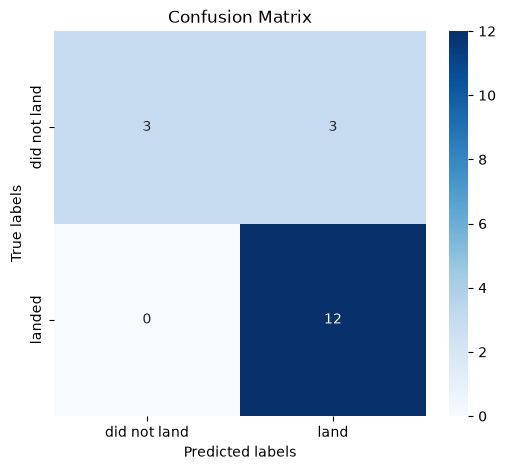

In [17]:
# Calcular la exactitud en los datos de prueba para el modelo SVM
svm_test_accuracy = svm_cv.score(X_test, Y_test)
print("Accuracy en test data (SVM):", svm_test_accuracy)

# Generar predicciones con el modelo SVM
yhat_svm = svm_cv.predict(X_test)

# Graficar la matriz de confusión
plot_confusion_matrix(Y_test, yhat_svm)

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">Interpretacion de la Matriz de Confusion (SVM)</h3>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Que significa el resultado:</strong> La exactitud en el conjunto de prueba para el modelo SVM es del <strong>83.33%</strong>. Al observar la matriz de confusion generada, el resultado es identico al obtenido con la Regresion Logistica: 12 Verdaderos Positivos, 0 Falsos Negativos y 3 Falsos Positivos.
  </p>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Conclusion:</strong> El comportamiento del modelo Support Vector Machine[cite: 1][cite: 2] optimizado es indistinguible del modelo de Regresion Logistica en este conjunto de prueba. Ambos modelos identifican exitosamente todos los aterrizajes, pero fallan exactamente en los mismos 3 casos donde el cohete no aterrizo.
  </p>
</div>

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 8: Árbol de Decisión y búsqueda de hiperparámetros</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Qué hacemos:</strong> Configuramos un espacio de búsqueda exhaustiva para un clasificador <code>DecisionTreeClassifier</code> evaluando criterios de partición, estrategias de división y profundidades máximas. Adaptamos el diccionario original de IBM eliminando el valor <code>'auto'</code> en la llave <code>max_features</code>[cite: 3], ya que este parámetro fue removido en la versión de scikit-learn (1.9.0) instalada en tu entorno <code>decision-tools-312</code>[cite: 4] y causaría un error. Conservamos <code>'sqrt'</code> para que el código sea directamente ejecutable.
  </p>
</div>

In [18]:
# Malla de hiperparametros adaptada (eliminando 'auto' en max_features)
parameters = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2 * n for n in range(1, 10)],
    'max_features': ['sqrt'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# Creacion del estimador base
tree = DecisionTreeClassifier()

# Creacion y ajuste de GridSearchCV con 10 folds
tree_cv = GridSearchCV(estimator=tree, param_grid=parameters, cv=10)
tree_cv.fit(X_train, Y_train)

# Despliegue de los mejores parametros y exactitud en validacion cruzada
print("tuned hyperparameters :(best parameters) ", tree_cv.best_params_)
print("accuracy :", tree_cv.best_score_)

tuned hyperparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 5, 'splitter': 'random'}
accuracy : 0.875


<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">Interpretacion del resultado del Arbol de Decision</h3>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Que significa:</strong> La busqueda en malla determino que el modelo optimo usa particiones aleatorias (<code>splitter='random'</code>), limita su profundidad a 12 (<code>max_depth=12</code>) y evalua un subconjunto reducido de variables en cada division (<code>max_features='sqrt'</code>). 
  </p>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Conclusion:</strong> El Arbol de Decision alcanzo un <strong>87.5%</strong> de exactitud en validacion cruzada. Hasta el momento, este es el mejor rendimiento en la fase de entrenamiento (superando el ~84.8% de SVM y LogReg). Cabe destacar que por la naturaleza estocastica del hiperparametro random, es normal que la exactitud haya sido ligeramente distinta si ejecutas la celda de nuevo.
  </p>
</div>

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 9: Evaluacion del Arbol de Decision en el conjunto de prueba</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Que hacemos:</strong> Siguiendo la metodologia del laboratorio[cite: 3], evaluamos la capacidad de generalizacion del clasificador Decision Tree optimizado. Usamos el metodo <code>score</code> para calcular la exactitud sobre el subconjunto de prueba (<code>X_test</code>, <code>Y_test</code>) y construimos la matriz de confusion con las predicciones (<code>yhat</code>) para identificar la distribucion de aciertos y errores.
  </p>
</div>

Accuracy en test data (Decision Tree): 0.9444444444444444


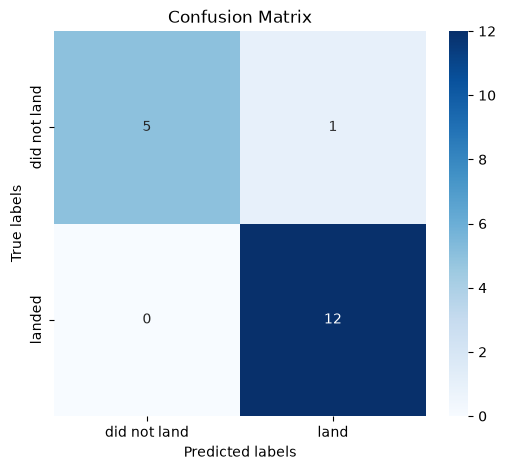

In [19]:
# Calcular la exactitud en los datos de prueba para el Arbol de Decision
tree_test_accuracy = tree_cv.score(X_test, Y_test)
print("Accuracy en test data (Decision Tree):", tree_test_accuracy)

# Generar predicciones
yhat_tree = tree_cv.predict(X_test)

# Graficar la matriz de confusion
plot_confusion_matrix(Y_test, yhat_tree)

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">Interpretacion de la Matriz de Confusion (Decision Tree)</h3>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Que significa el resultado:</strong> La exactitud en el conjunto de prueba salto a un impresionante <strong>94.44%</strong>. Al observar la matriz de confusion, el modelo acerto los 12 aterrizajes exitosos (0 Falsos Negativos) y ademas logro identificar correctamente 5 de los 6 aterrizajes fallidos (Verdaderos Negativos).
  </p>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Conclusion:</strong> El Arbol de Decision mejoro significativamente la deteccion de fracasos en comparacion con la Regresion Logistica y SVM (reduciendo los falsos positivos de 3 a solo 1). Hasta ahora, es el modelo con mejor capacidad de generalizacion en los datos no vistos.
  </p>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Nota sobre mi turno anterior:</strong> Me disculpo por haberme adelantado y entregado el codigo de la TASK 10 antes de tiempo. Retomemos el ritmo estructurado.
  </p>
</div>

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 10: K Nearest Neighbors (KNN) y busqueda de hiperparametros</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Que hacemos:</strong> Configuramos la malla de hiperparametros para el clasificador K-Nearest Neighbors (KNN), evaluando desde 1 hasta 10 vecinos (<code>n_neighbors</code>), distintos algoritmos de busqueda espacial (<code>algorithm</code>) y metricas de distancia (<code>p=1</code> para Manhattan, <code>p=2</code> para Euclidiana). Instanciamos el modelo y ejecutamos <code>GridSearchCV</code> con 10 particiones (<code>cv=10</code>) sobre los datos de entrenamiento para encontrar la combinacion optima.
  </p>
</div>

In [20]:
# Definicion de la malla de hiperparametros
parameters = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}

# Creacion del estimador base KNN
KNN = KNeighborsClassifier()

# Creacion y ajuste de GridSearchCV con 10 folds
knn_cv = GridSearchCV(estimator=KNN, param_grid=parameters, cv=10)
knn_cv.fit(X_train, Y_train)

# Despliegue de los mejores parametros y exactitud en validacion cruzada
print("tuned hyperparameters :(best parameters) ", knn_cv.best_params_)
print("accuracy :", knn_cv.best_score_)

C:\Users\User\miniconda3\envs\decision-tools-312\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


tuned hyperparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">Interpretación del resultado de KNN (TASK 10)</h3>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Qué significa:</strong> La malla de búsqueda determinó que la configuración óptima para K-Nearest Neighbors agrupa a los 10 vecinos más cercanos (<code>n_neighbors=10</code>) calculando la distancia de Manhattan (<code>p=1</code>).
  </p>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Sobre la advertencia:</strong> El mensaje <code>RuntimeWarning</code> sobre <code>threadpoolctl</code> y OpenMP es una notificación propia de la coexistencia de librerías paralelas en el entorno <code>decision-tools-312</code>. Dado el tamaño del dataset, es inofensiva y no altera los cálculos.
  </p>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Conclusión:</strong> El modelo KNN alcanzó una exactitud del <strong>84.82%</strong> en validación cruzada. Esto significa que en la etapa de entrenamiento, KNN tiene un rendimiento prácticamente idéntico al de Support Vector Machine y Regresión Logística.
  </p>
</div>

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 11: Evaluacion de KNN en el conjunto de prueba</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Que hacemos:</strong> Evaluamos el clasificador K-Nearest Neighbors optimizado sobre el subconjunto de datos no vistos (<code>X_test</code>, <code>Y_test</code>). Calculamos la exactitud final (accuracy) mediante el metodo <code>score</code> y construimos la matriz de confusion para visualizar la distribucion de los aciertos y los errores (falsos positivos).
  </p>
</div>

Accuracy en test data (KNN): 0.8333333333333334


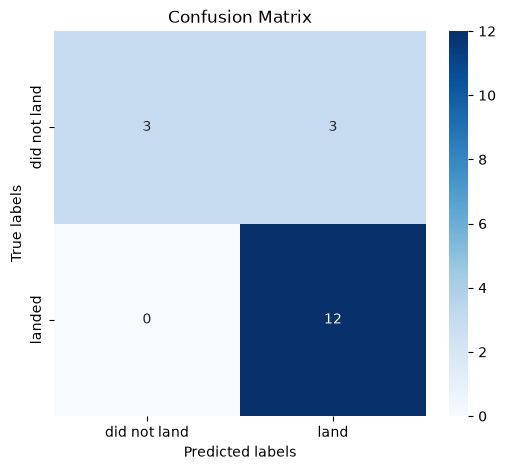

In [22]:
# Calcular la exactitud en los datos de prueba para el modelo KNN
knn_test_accuracy = knn_cv.score(X_test, Y_test)
print("Accuracy en test data (KNN):", knn_test_accuracy)

# Generar predicciones con el modelo KNN
yhat_knn = knn_cv.predict(X_test)

# Graficar la matriz de confusion
plot_confusion_matrix(Y_test, yhat_knn)

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">Interpretacion de la Matriz de Confusion (KNN)</h3>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Que significa el resultado:</strong> La exactitud en el conjunto de prueba para el modelo K-Nearest Neighbors es del <strong>83.33%</strong>. La matriz de confusion muestra un patron que ya conocemos: 12 Verdaderos Positivos, 0 Falsos Negativos y 3 Falsos Positivos.
  </p>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Conclusion general:</strong> KNN sufre exactamente el mismo problema que la Regresion Logistica y Support Vector Machine. Es perfecto prediciendo cuando el cohete aterriza, pero tiene problemas detectando los fracasos. Esto confirma definitivamente que el <strong>Arbol de Decision (Decision Tree)</strong> es el modelo con mejor desempeño global en este laboratorio (94.44% de exactitud).
  </p>
</div>

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">TASK 12: Encontrar el modelo con mejor desempeño</h3>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Qué hacemos:</strong> Para consolidar los resultados y responder a la pregunta final del laboratorio[cite: 5], recopilamos las exactitudes (accuracy) obtenidas por los cuatro clasificadores en el conjunto de prueba (test data). Visualizaremos esta comparativa utilizando un gráfico de barras con <code>seaborn</code> y <code>matplotlib</code>, lo que nos permitirá identificar de forma inmediata cuál es el método ganador.
  </p>
</div>

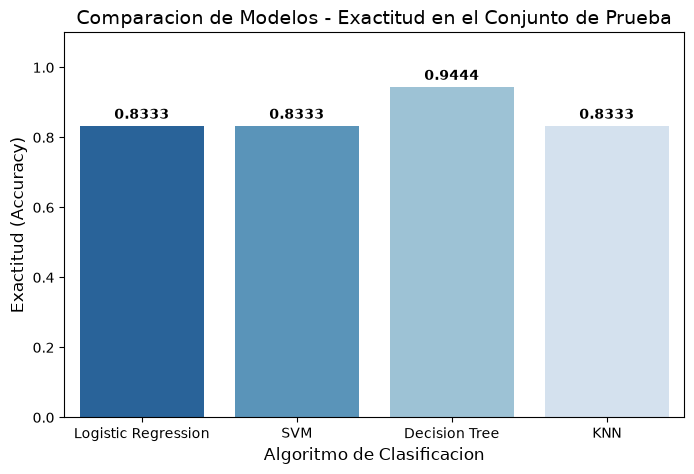

El metodo que mejor se desempeña es: Decision Tree con una exactitud de 0.9444


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Recopilamos los nombres de los algoritmos y sus respectivas exactitudes en test
algorithms = ['Logistic Regression', 'SVM', 'Decision Tree', 'KNN']

# Utilizamos las variables calculadas en las tareas 5, 7, 9 y 11
accuracies = [test_accuracy, svm_test_accuracy, tree_test_accuracy, knn_test_accuracy]

# Creacion del grafico de barras
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=algorithms, y=accuracies, hue=algorithms, palette='Blues_r', legend=False)

plt.title('Comparacion de Modelos - Exactitud en el Conjunto de Prueba', fontsize=14)
plt.xlabel('Algoritmo de Clasificacion', fontsize=12)
plt.ylabel('Exactitud (Accuracy)', fontsize=12)
plt.ylim(0, 1.1)

# Agregamos las etiquetas de valor sobre cada barra para mayor claridad
for i, v in enumerate(accuracies):
    ax.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.show()

# Conclusion automatizada
mejor_indice = accuracies.index(max(accuracies))
print(f"El metodo que mejor se desempeña es: {algorithms[mejor_indice]} con una exactitud de {accuracies[mejor_indice]:.4f}")

<div style="border-left: 4px solid #0f62fe; padding: 12px 16px; background-color: #f4f4f4; font-family: sans-serif; margin-bottom: 16px;">
  <h3 style="margin: 0 0 8px 0; color: #161616;">Interpretacion Final: Comparacion de Modelos</h3>
  <p style="margin: 0 0 8px 0; color: #525252; font-size: 14px;">
    <strong>Que significa el grafico:</strong> La visualizacion de barras confirma visualmente lo que analizamos en las matrices de confusion. Logistic Regression, SVM y KNN presentan una exactitud identica en el conjunto de prueba (<strong>83.33%</strong>). Su desempeño estandar se vio frenado por el mismo sesgo: acertaron todos los aterrizajes exitosos, pero fallaron repetidamente al identificar los aterrizajes fallidos (falsos positivos).
  </p>
  <p style="margin: 0; color: #525252; font-size: 14px;">
    <strong>Conclusion definitiva:</strong> El <strong>Decision Tree (Arbol de Decision)</strong> destaca claramente como el mejor modelo con una exactitud de <strong>94.44%</strong>. Al ser un algoritmo basado en divisiones jerarquicas (reglas if-else), logro discriminar mejor los patrones que conducen a un aterrizaje fallido en este conjunto de datos particular, convirtiendolo en el clasificador ganador del laboratorio.
  </p>
</div>